## 1. Imports & Config

In [1]:
# Install dependencies (run once)
!pip install yfinance keras tensorflow scikit-learn pandas numpy matplotlib seaborn
!pip install keras-tuner --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 8.1 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.stattools import durbin_watson

import keras
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

plt.style.use('fivethirtyeight')
sns.set_palette('husl')

# ── CONFIG ────────────────────────────────────────────────────────────────────
SYMBOL         = 'BBCA.JK'
START_DATE     = '2015-01-01'
TIME_STEPS     = 60
TRAIN_RATIO    = 0.75
FUTURE_DAYS    = 30
EPOCHS         = 150
BATCH_SIZE     = 32
MODEL_PATH     = 'bbca_lstm_best_v4.keras'
N_SPLITS       = 3

# ── Key toggle: predict returns (True) or price levels (False)
# True  → fixes the lag problem; model must learn actual change
# False → keep original price-level prediction for comparison
PREDICT_RETURNS = False

EMA_PERIODS = [9, 21, 50, 200]

FEATURES = [
    'Close', 'Volume', 'HL_Range', 'Daily_Return',
    'EMA_9', 'EMA_21', 'EMA_50', 'EMA_200',
    'EMA_9_21_ratio',
    'EMA_50_200_ratio',
    'Close_EMA50_gap',
    # New v4 features
    'Realized_Vol_20',
    'Vol_Regime',
]

TARGET_COL = 'Close'

print(f'Keras {keras.__version__} | N_SPLITS={N_SPLITS} | TRAIN_RATIO={TRAIN_RATIO}')
print(f'PREDICT_RETURNS = {PREDICT_RETURNS}  '
      f'({"return-based target (lag fix)" if PREDICT_RETURNS else "price-level target"})')

Keras 3.13.2 | N_SPLITS=3 | TRAIN_RATIO=0.75
PREDICT_RETURNS = False  (price-level target)


## 2. Download & Feature Engineering

In [49]:
raw = yf.download(SYMBOL, start=START_DATE, auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

raw.dropna(inplace=True)
print(f'Downloaded {len(raw):,} rows  |  {raw.index[0].date()} → {raw.index[-1].date()}')
print(f"Rows: {len(raw)}")
print(f"Date range: {raw.index[0].date()} → {raw.index[-1].date()}")
print(raw.head(3))
print(raw.tail(3))
raw.tail(3)

Downloaded 2,816 rows  |  2015-01-02 → 2026-06-12
Rows: 2816
Date range: 2015-01-02 → 2026-06-12
Price             Close         High          Low         Open    Volume
Date                                                                    
2015-01-02  2066.488281  2074.301091  2054.769066  2074.301091  29302500
2015-01-05  2062.581055  2062.581055  2050.861844  2054.768248  25434500
2015-01-06  2046.956177  2062.581796  2031.330557  2031.330557  48681500
Price        Close    High     Low    Open     Volume
Date                                                 
2026-06-10  5650.0  5700.0  5175.0  5175.0  747366000
2026-06-11  5825.0  5875.0  5550.0  5650.0  543032300
2026-06-12  5925.0  6100.0  5900.0  6000.0  415872300


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-10,5650.0,5700.0,5175.0,5175.0,747366000
2026-06-11,5825.0,5875.0,5550.0,5650.0,543032300
2026-06-12,5925.0,6100.0,5900.0,6000.0,415872300


In [ ]:
df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# ── Base features ─────────────────────────────────────────────────────────────
df['HL_Range']     = df['High'] - df['Low']
df['Daily_Return'] = df['Close'].pct_change()

# ── EMA features ──────────────────────────────────────────────────────────────
for p in EMA_PERIODS:
    df[f'EMA_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

df['EMA_9_21_ratio']   = df['EMA_9']  / df['EMA_21']
df['EMA_50_200_ratio'] = df['EMA_50'] / df['EMA_200']
df['Close_EMA50_gap']  = (df['Close'] - df['EMA_50']) / df['EMA_50']

# ── NEW v4: Volatility Regime features ────────────────────────────────────────
# Realized 20-day annualised volatility — tells model when markets are turbulent
df['Realized_Vol_20'] = df['Daily_Return'].rolling(20).std() * np.sqrt(252)
vol_threshold = df['Realized_Vol_20'].quantile(0.75)
df['Vol_Regime'] = (df['Realized_Vol_20'] > vol_threshold).astype(float)

df.dropna(inplace=True)

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Vol threshold (75th pct): {vol_threshold:.3f}  '
      f'({df["Vol_Regime"].mean()*100:.1f}% of days flagged high-vol)')
print(f'Rows after dropna: {len(df):,}')

Features (13): ['Close', 'Volume', 'HL_Range', 'Daily_Return', 'EMA_9', 'EMA_21', 'EMA_50', 'EMA_200', 'EMA_9_21_ratio', 'EMA_50_200_ratio', 'Close_EMA50_gap', 'Realized_Vol_20', 'Vol_Regime']
Vol threshold (75th pct): 0.258  (25.0% of days flagged high-vol)
Rows after dropna: 2,796


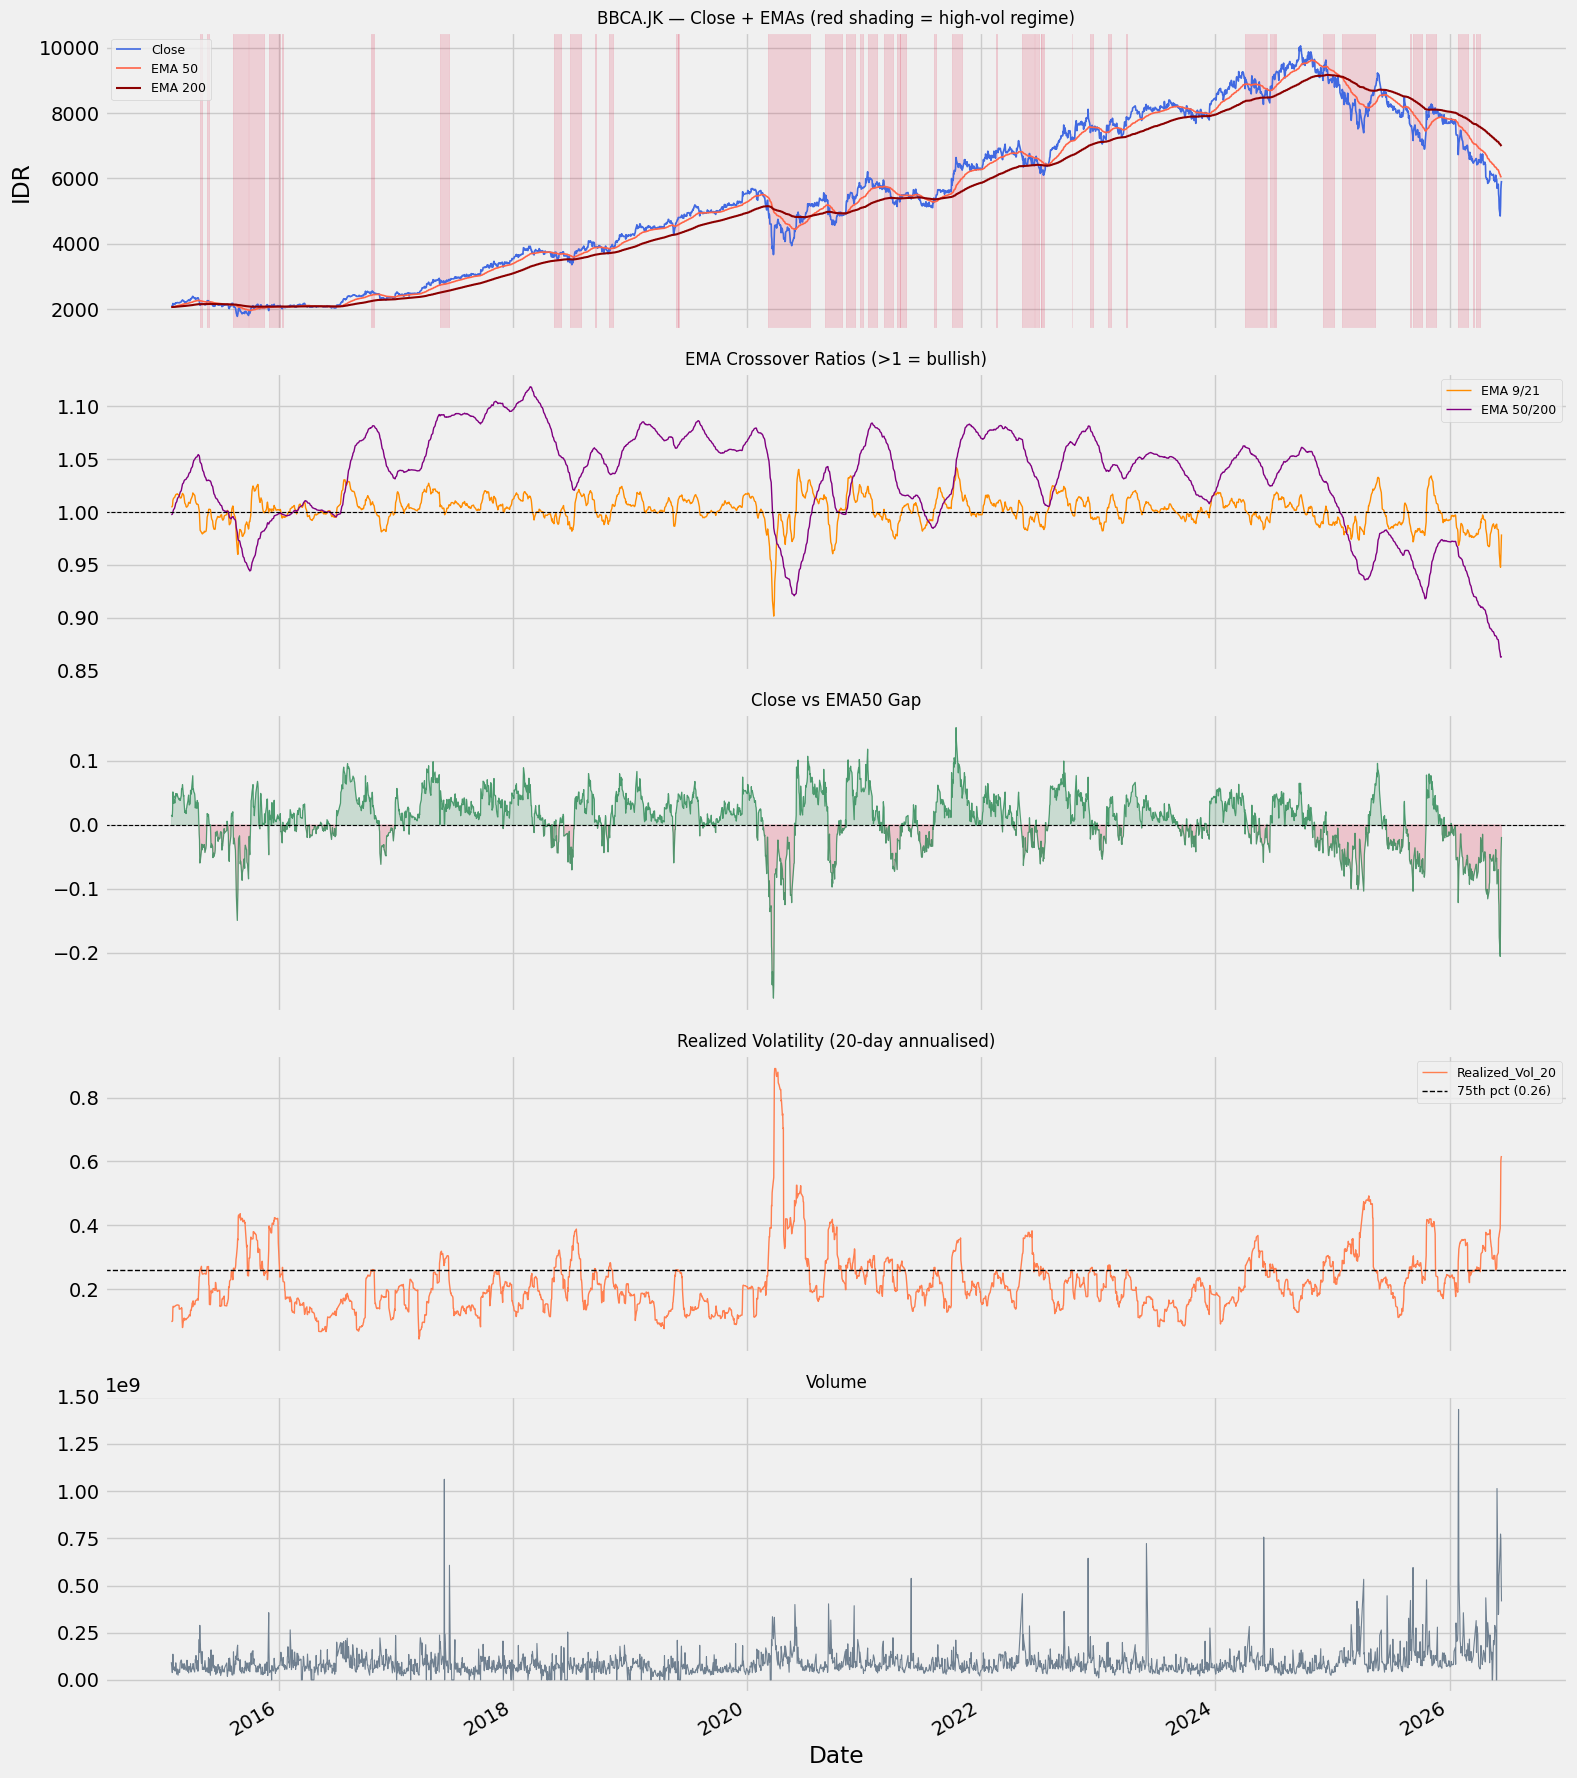

In [51]:
# ── EDA — now includes vol regime ─────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

# Panel 1: Close + EMAs with vol regime shading
df['Close'].plot(ax=axes[0], color='royalblue', linewidth=1.2, label='Close')
df['EMA_50'].plot(ax=axes[0],  color='tomato',  linewidth=1.2, linestyle='-',  label='EMA 50')
df['EMA_200'].plot(ax=axes[0], color='darkred', linewidth=1.5, linestyle='-',  label='EMA 200')
# Shade high-vol periods
in_regime = False
start_idx = None
for i, (idx, row) in enumerate(df.iterrows()):
    if row['Vol_Regime'] == 1 and not in_regime:
        start_idx = idx; in_regime = True
    elif row['Vol_Regime'] == 0 and in_regime:
        axes[0].axvspan(start_idx, idx, alpha=0.15, color='crimson')
        in_regime = False
axes[0].set_title(f'{SYMBOL} — Close + EMAs (red shading = high-vol regime)', fontsize=12)
axes[0].set_ylabel('IDR'); axes[0].legend(fontsize=9)

# Panel 2: EMA crossover ratios
df['EMA_9_21_ratio'].plot(ax=axes[1],   color='darkorange', linewidth=1, label='EMA 9/21')
df['EMA_50_200_ratio'].plot(ax=axes[1], color='purple',     linewidth=1, label='EMA 50/200')
axes[1].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('EMA Crossover Ratios (>1 = bullish)', fontsize=12); axes[1].legend(fontsize=9)

# Panel 3: Close/EMA50 gap
df['Close_EMA50_gap'].plot(ax=axes[2], color='seagreen', linewidth=0.9, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].fill_between(df.index, df['Close_EMA50_gap'], 0,
                     where=df['Close_EMA50_gap'] >= 0, alpha=0.2, color='seagreen')
axes[2].fill_between(df.index, df['Close_EMA50_gap'], 0,
                     where=df['Close_EMA50_gap'] < 0,  alpha=0.2, color='crimson')
axes[2].set_title('Close vs EMA50 Gap', fontsize=12)

# Panel 4: Realized vol
df['Realized_Vol_20'].plot(ax=axes[3], color='coral', linewidth=1)
axes[3].axhline(vol_threshold, color='black', linestyle='--', linewidth=1,
                label=f'75th pct ({vol_threshold:.2f})')
axes[3].set_title('Realized Volatility (20-day annualised)', fontsize=12)
axes[3].legend(fontsize=9)

# Panel 5: Volume
df['Volume'].plot(ax=axes[4], color='slategray', linewidth=0.8)
axes[4].set_title('Volume', fontsize=12)

plt.tight_layout(); plt.show()

## 3. Preprocessing

**If `PREDICT_RETURNS = True`:** the model predicts `Daily_Return[t+1]` (next-day % change) instead of `Close[t+1]`.
Price is then reconstructed as `Close[t] * (1 + pred_return[t+1])`.
This forces the model to learn *change*, not level, which eliminates the 1-day lag.

In [ ]:
from sklearn.preprocessing import StandardScaler

data = df[FEATURES].values
n_features = len(FEATURES)
target_idx = FEATURES.index(TARGET_COL)

if PREDICT_RETURNS:
    returns_series = df['Daily_Return'].values
    target_returns = returns_series[1:]
    data_X         = data[:-1]
    close_prices   = df['Close'].values[:-1]
    print('Target: next-day return (PREDICT_RETURNS=True)')
else:
    target_returns = None
    data_X         = data
    close_prices   = df['Close'].values
    ret_scaler     = None
    print('Target: price level (PREDICT_RETURNS=False)')

train_size = int(len(data_X) * TRAIN_RATIO)
print(f'Train: {train_size:,} rows  |  Test: {len(data_X)-train_size:,} rows')

# Scaler fit on train only (no leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(data_X[:train_size])
scaled = scaler.transform(data_X)

train_scaled = scaled[:train_size]
test_scaled  = scaled[train_size - TIME_STEPS:]

if PREDICT_RETURNS:
    # ── StandardScaler for returns (replaces MinMaxScaler) ────────────────────
    # MinMaxScaler compresses returns into tiny range due to crash outliers
    # StandardScaler preserves sign and gives balanced +/- values for training
    ret_scaler = StandardScaler()
    ret_train  = target_returns[:train_size].reshape(-1, 1)
    ret_scaler.fit(ret_train)
    returns_scaled = ret_scaler.transform(
                         target_returns.reshape(-1, 1)).flatten()

    # Sanity check — should see range ≈ -3 to +3, mean ≈ 0, std ≈ 1
    print(f'returns_scaled range: {returns_scaled.min():.3f} → {returns_scaled.max():.3f}')
    print(f'returns_scaled mean : {returns_scaled.mean():.4f}')
    print(f'returns_scaled std  : {returns_scaled.std():.4f}')

    ret_train_scaled = returns_scaled[:train_size]
    ret_test_scaled  = returns_scaled[train_size - TIME_STEPS:]


def build_sequences(X_arr, y_arr, time_steps, n_feat):
    X, y = [], []
    for i in range(time_steps, len(X_arr)):
        X.append(X_arr[i - time_steps:i, :n_feat])
        y.append(y_arr[i])
    return np.array(X), np.array(y)


if PREDICT_RETURNS:
    X_train, y_train = build_sequences(train_scaled, returns_scaled[:train_size], TIME_STEPS, n_features)
    X_test,  y_test  = build_sequences(test_scaled,  returns_scaled[train_size - TIME_STEPS:], TIME_STEPS, n_features)
else:
    def build_sequences_price(arr, time_steps, n_feat, t_idx):
        X, y = [], []
        for i in range(time_steps, len(arr)):
            X.append(arr[i - time_steps:i, :n_feat])
            y.append(arr[i, t_idx])
        return np.array(X), np.array(y)
    X_train, y_train = build_sequences_price(train_scaled, TIME_STEPS, n_features, target_idx)
    X_test,  y_test  = build_sequences_price(test_scaled,  TIME_STEPS, n_features, target_idx)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

Target: price level (PREDICT_RETURNS=False)
Train: 2,097 rows  |  Test: 699 rows
X_train: (2037, 60, 13)  y_train: (2037,)
X_test : (699, 60, 13)   y_test : (699,)


## 4. Inspect Keras Tuner Results

Before committing to full CV, review the **top-5 trials**, not just the winner.
If they converge → hyperparameters are well-identified.
If they scatter → run more trials (increase `max_trials` to 25).

In [ ]:
import keras_tuner as kt
from sklearn.model_selection import TimeSeriesSplit

def build_hypermodel(hp):
    lstm_units_1 = hp.Choice('lstm_units_1', values=[64, 128, 256])
    lstm_units_2 = hp.Choice('lstm_units_2', values=[32, 64, 128])
    dropout_rate = hp.Float('dropout', min_value=0.1, max_value=0.4, step=0.1)
    dense_units  = hp.Choice('dense_units', values=[32, 64, 128])
    lr           = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])

    model = Sequential([
        Input(shape=(TIME_STEPS, n_features)),
        Bidirectional(LSTM(lstm_units_1, return_sequences=True)),
        Dropout(dropout_rate),
        LSTM(lstm_units_2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(dense_units, activation='relu'),
        Dense(1)
    ])
    loss = 'mse' if PREDICT_RETURNS else 'huber'
    model.compile(optimizer=Adam(learning_rate=lr), loss=loss, metrics=['mae'])
    return model

In [55]:
# ── Run tuner (or reload if already done) ─────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X_train))
mid_fold = len(splits) // 2
train_idx, val_idx = splits[mid_fold]
X_tune, y_tune = X_train[train_idx], y_train[train_idx]
X_val,  y_val  = X_train[val_idx],  y_train[val_idx]

print(f'Tuning on fold {mid_fold+1}/{N_SPLITS}')
print(f'  Tune train : {len(X_tune):,} rows')
print(f'  Tune val   : {len(X_val):,} rows')

tuner = kt.BayesianOptimization(
    build_hypermodel,
    objective='val_loss',
    max_trials=25,
    num_initial_points=5,
    directory='kt_tuning_v4',
    project_name='bbca_lstm_v4',
    overwrite=True
)

tuner.search(
    X_tune, y_tune,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
    ],
    verbose=1
)

Trial 25 Complete [00h 00m 26s]
val_loss: 0.0003589773259591311

Best val_loss So Far: 0.00031828758073970675
Total elapsed time: 00h 09m 10s


In [56]:
# ── NEW v4: Inspect top-5 trials before committing ────────────────────────────
top5_hps = tuner.get_best_hyperparameters(num_trials=5)

print('Top-5 Keras Tuner Trials:')
print(f'{"Rank":<5} {"lstm1":<8} {"lstm2":<8} {"dropout":<10} {"dense":<8} {"lr":<10}')
print('─' * 55)
for i, hp in enumerate(top5_hps, 1):
    print(f'{i:<5} {hp.get("lstm_units_1"):<8} {hp.get("lstm_units_2"):<8} '
          f'{hp.get("dropout"):<10.1f} {hp.get("dense_units"):<8} {hp.get("learning_rate"):<10}')

best_hps = top5_hps[0]

# Convergence check: are the top trials similar?
lstm1_vals = [hp.get('lstm_units_1') for hp in top5_hps]
print(f'\nlstm_units_1 across top-5: {lstm1_vals}')
if len(set(lstm1_vals)) == 1:
    print('✅ Converged — hyperparameter well-identified, proceed with CV.')
else:
    print('⚠️  Scattered — consider increasing max_trials to 25 for more confidence.')

print(f'\n✅ Using best hyperparameters:')
print(f'   lstm_units_1 = {best_hps.get("lstm_units_1")}')
print(f'   lstm_units_2 = {best_hps.get("lstm_units_2")}')
print(f'   dropout      = {best_hps.get("dropout")}')
print(f'   dense_units  = {best_hps.get("dense_units")}')
print(f'   learning_rate= {best_hps.get("learning_rate")}')

Top-5 Keras Tuner Trials:
Rank  lstm1    lstm2    dropout    dense    lr        
───────────────────────────────────────────────────────
1     256      128      0.1        32       0.001     
2     256      128      0.1        32       0.001     
3     256      128      0.1        128      0.0005    
4     256      128      0.1        64       0.001     
5     256      128      0.1        128      0.0005    

lstm_units_1 across top-5: [256, 256, 256, 256, 256]
✅ Converged — hyperparameter well-identified, proceed with CV.

✅ Using best hyperparameters:
   lstm_units_1 = 256
   lstm_units_2 = 128
   dropout      = 0.1
   dense_units  = 32
   learning_rate= 0.001


## 5. Train Best Model with Time-Series CV (N_SPLITS=3)

In [ ]:
def build_model(time_steps, n_features, hps=None):
    if hps:
        u1 = hps.get('lstm_units_1')
        u2 = hps.get('lstm_units_2')
        dr = hps.get('dropout')
        du = hps.get('dense_units')
        lr = hps.get('learning_rate')
    else:
        u1, u2, dr, du, lr = 128, 64, 0.2, 64, 1e-3

    model = Sequential([
        Input(shape=(time_steps, n_features)),
        Bidirectional(LSTM(u1, return_sequences=True)),
        Dropout(dr),
        LSTM(u2, return_sequences=False),
        Dropout(dr),
        Dense(du, activation='relu'),
        Dense(1)
    ])
    loss = 'mse' if PREDICT_RETURNS else 'huber'
    model.compile(optimizer=Adam(learning_rate=lr), loss=loss, metrics=['mae'])
    return model

# ── Manual walk-forward folds (guaranteed balanced) ───────────────────────────
print(f"DEBUG: n_total={len(X_train)}, val_size=400, N_SPLITS={N_SPLITS}")
n_total  = len(X_train)
val_size = 400

manual_folds = []
for fold_i in range(N_SPLITS):
    val_end   = n_total - (N_SPLITS - 1 - fold_i) * val_size
    val_start = val_end - val_size
    train_end = val_start

    if train_end < 250:
        print(f"Fold {fold_i+1} skipped — only {train_end} train rows (too few)")
        continue

    manual_folds.append((np.arange(0, train_end), np.arange(val_start, val_end)))

print("Fold date ranges:")
for i, (tr, vl) in enumerate(manual_folds, 1):
    print(f"  Fold {i}: "
          f"train {df.index[tr[0]].date()}→{df.index[tr[-1]].date()} "
          f"({len(tr)} rows) | "
          f"val {df.index[vl[0]].date()}→{df.index[vl[-1]].date()} "
          f"({len(vl)} rows)")

# ── Run CV ────────────────────────────────────────────────────────────────────
fold_histories        = []
fold_val_losses       = []
best_overall_val_loss = np.inf

print(f'\nRunning {len(manual_folds)}-fold walk-forward CV...\n')

for fold, (train_idx, val_idx) in enumerate(manual_folds, 1):
    print(f'{"─"*55}')
    print(f'Fold {fold}/{len(manual_folds)}  |  '
          f'train: {len(train_idx):,}  |  val: {len(val_idx):,}')

    X_tr, y_tr = X_train[train_idx], y_train[train_idx]
    X_vl, y_vl = X_train[val_idx],  y_train[val_idx]

    fold_model = build_model(TIME_STEPS, n_features, hps=best_hps)

    hist = fold_model.fit(
        X_tr, y_tr,
        validation_data=(X_vl, y_vl),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=15,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=5, min_lr=1e-6, verbose=0),
        ],
        verbose=1
    )

    best_val = min(hist.history['val_loss'])
    fold_val_losses.append(best_val)
    fold_histories.append(hist.history)
    print(f'Fold {fold} best val_loss: {best_val:.6f}  '
          f'(stopped at epoch {len(hist.history["loss"])})')

    if best_val < best_overall_val_loss:
        best_overall_val_loss = best_val
        fold_model.save(MODEL_PATH)
        print(f'  ✅ New best model saved (fold {fold})')

print(f'\n{"═"*55}')
print(f'CV Results ({len(manual_folds)} folds):')
for i, v in enumerate(fold_val_losses, 1):
    print(f'  Fold {i}: {v:.6f}')
print(f'  Mean : {np.mean(fold_val_losses):.6f}')
print(f'  Std  : {np.std(fold_val_losses):.6f}')
print(f'  Best : {min(fold_val_losses):.6f}  → saved to {MODEL_PATH}')
print(f'{"═"*55}')

DEBUG: n_total=2037, val_size=400, N_SPLITS=3
Fold date ranges:
  Fold 1: train 2015-01-30→2018-06-05 (837 rows) | val 2018-06-06→2019-12-17 (400 rows)
  Fold 2: train 2015-01-30→2019-12-17 (1237 rows) | val 2019-12-18→2021-08-16 (400 rows)
  Fold 3: train 2015-01-30→2021-08-16 (1637 rows) | val 2021-08-18→2023-03-27 (400 rows)

Running 3-fold walk-forward CV...

───────────────────────────────────────────────────────
Fold 1/3  |  train: 837  |  val: 400
Epoch 1/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0030 - mae: 0.0506 - val_loss: 5.3915e-04 - val_mae: 0.0265 - learning_rate: 0.0010
Epoch 2/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.7175e-04 - mae: 0.0175 - val_loss: 5.8480e-04 - val_mae: 0.0289 - learning_rate: 0.0010
Epoch 3/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.8606e-04 - mae: 0.0145 - val_loss: 6.9470e-04 - val_mae: 0.0321 - learning_rate: 0.0010
Epoch 4/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.4830e-04 - mae: 0.0133 - val_loss

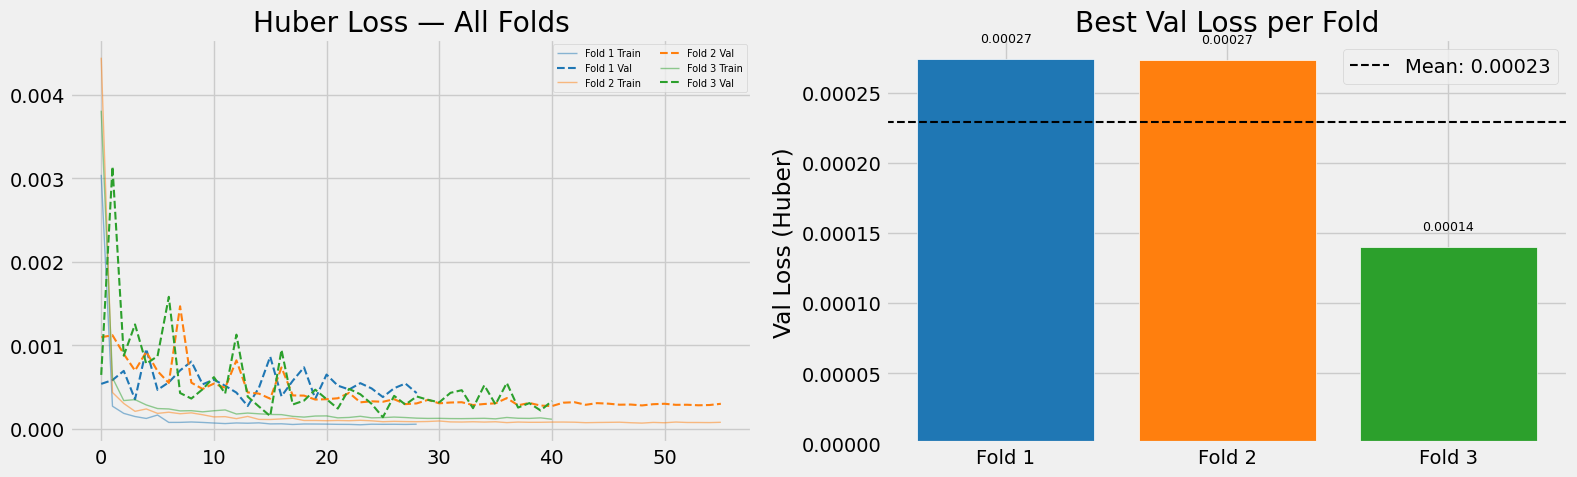

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.tab10.colors

for i, hist in enumerate(fold_histories):
    axes[0].plot(hist['loss'],     color=colors[i], lw=1,   ls='-',  alpha=0.5, label=f'Fold {i+1} Train')
    axes[0].plot(hist['val_loss'], color=colors[i], lw=1.5, ls='--',            label=f'Fold {i+1} Val')
loss_name = 'MSE' if PREDICT_RETURNS else 'Huber'
axes[0].set_title(f'{loss_name} Loss — All Folds')
axes[0].legend(fontsize=7, ncol=2)

bars = axes[1].bar([f'Fold {i+1}' for i in range(N_SPLITS)],
                   fold_val_losses, color=colors[:N_SPLITS], edgecolor='white')
axes[1].axhline(np.mean(fold_val_losses), color='black', ls='--', lw=1.5,
                label=f'Mean: {np.mean(fold_val_losses):.5f}')
axes[1].set_title('Best Val Loss per Fold'); axes[1].set_ylabel(f'Val Loss ({loss_name})')
axes[1].legend()
for bar, v in zip(bars, fold_val_losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e-5,
                 f'{v:.5f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(); plt.show()

## 6. Evaluate on Test Set

In [ ]:
# ── Load best saved weights then predict ─────────────────────────────────────
best_model = load_model(MODEL_PATH)
pred_scaled = best_model.predict(X_test, verbose=0)


def inverse_close(scaled_1d, scaler, n_features, target_idx):
    dummy = np.zeros((len(scaled_1d), n_features))
    dummy[:, target_idx] = scaled_1d.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]


if PREDICT_RETURNS:
    pred_returns   = ret_scaler.inverse_transform(
                         pred_scaled.reshape(-1, 1)).flatten()
    actual_returns = ret_scaler.inverse_transform(
                         y_test.reshape(-1, 1)).flatten()

    print(f"pred_returns   range: {pred_returns.min():.4f} → {pred_returns.max():.4f}")
    print(f"actual_returns range: {actual_returns.min():.4f} → {actual_returns.max():.4f}")

    # Use actual previous close for 1-step reconstruction
    test_close_actual = close_prices[train_size : train_size + len(y_test)]
    test_close_prev   = close_prices[train_size - 1 : train_size + len(y_test) - 1]

    actual_prices = test_close_actual
    pred_prices   = test_close_prev * (1 + pred_returns)

    print(f"\nactual_prices[:5] : {actual_prices[:5]}")
    print(f"pred_prices[:5]   : {pred_prices[:5]}")
    print(f"actual range      : {actual_prices.min():.0f} → {actual_prices.max():.0f}")
    print(f"pred range        : {pred_prices.min():.0f} → {pred_prices.max():.0f}")

else:
    pred_prices   = inverse_close(pred_scaled, scaler, n_features, target_idx)
    actual_prices = inverse_close(y_test,      scaler, n_features, target_idx)


# ── Metrics ───────────────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
mae  = mean_absolute_error(actual_prices, pred_prices)
mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100
r2   = r2_score(actual_prices, pred_prices)

# Directional Accuracy
actual_dir = np.sign(actual_prices[1:] - actual_prices[:-1])
pred_dir   = np.sign(pred_prices[1:]   - pred_prices[:-1])
dir_acc    = np.mean(actual_dir == pred_dir) * 100

print('\n' + '─' * 50)
print(f'  RMSE              : {rmse:>12,.2f} IDR')
print(f'  MAE               : {mae:>12,.2f} IDR')
print(f'  MAPE              : {mape:>11.2f} %')
print(f'  R²                : {r2:>12.4f}')
print(f'  Directional Acc   : {dir_acc:>11.2f} %')
print('─' * 50)
if dir_acc > 55:
    print('  ✅ >55% directional accuracy — model has predictive signal')
elif dir_acc > 50:
    print('  ⚠️  50–55% — marginally better than a coin flip')
else:
    print('  ❌ ≤50% — model is not reliably capturing direction')


──────────────────────────────────────────────────
  RMSE              :       181.46 IDR
  MAE               :       143.17 IDR
  MAPE              :        1.83 %
  R²                :       0.9628
  Directional Acc   :       39.40 %
──────────────────────────────────────────────────
  ❌ ≤50% — model is not reliably capturing direction


In [60]:
print("=== SANITY CHECK ===")
print(f"actual_prices[:5]  : {actual_prices[:5]}")
print(f"pred_prices[:5]    : {pred_prices[:5]}")
print(f"actual_prices[-5:] : {actual_prices[-5:]}")
print(f"pred_prices[-5:]   : {pred_prices[-5:]}")
print(f"actual price range : {actual_prices.min():.0f} → {actual_prices.max():.0f}")
print(f"pred price range   : {pred_prices.min():.0f} → {pred_prices.max():.0f}")
if PREDICT_RETURNS:
    print(f"pred_returns[:5]   : {pred_returns[:5]}")
    print(f"actual_returns[:5] : {actual_returns[:5]}")

=== SANITY CHECK ===
actual_prices[:5]  : [8066.67822266 8089.02392578 8066.67822266 8200.75097656 8156.06054688]
pred_prices[:5]    : [8171.12539455 8154.73654029 8160.80131388 8150.00217152 8203.62069671]
actual_prices[-5:] : [4850. 5150. 5650. 5825. 5925.]
pred_prices[-5:]   : [5503.11439086 5317.13625377 5418.34760323 5684.70130227 5830.20673743]
actual price range : 4850 → 10061
pred price range   : 5317 → 9890


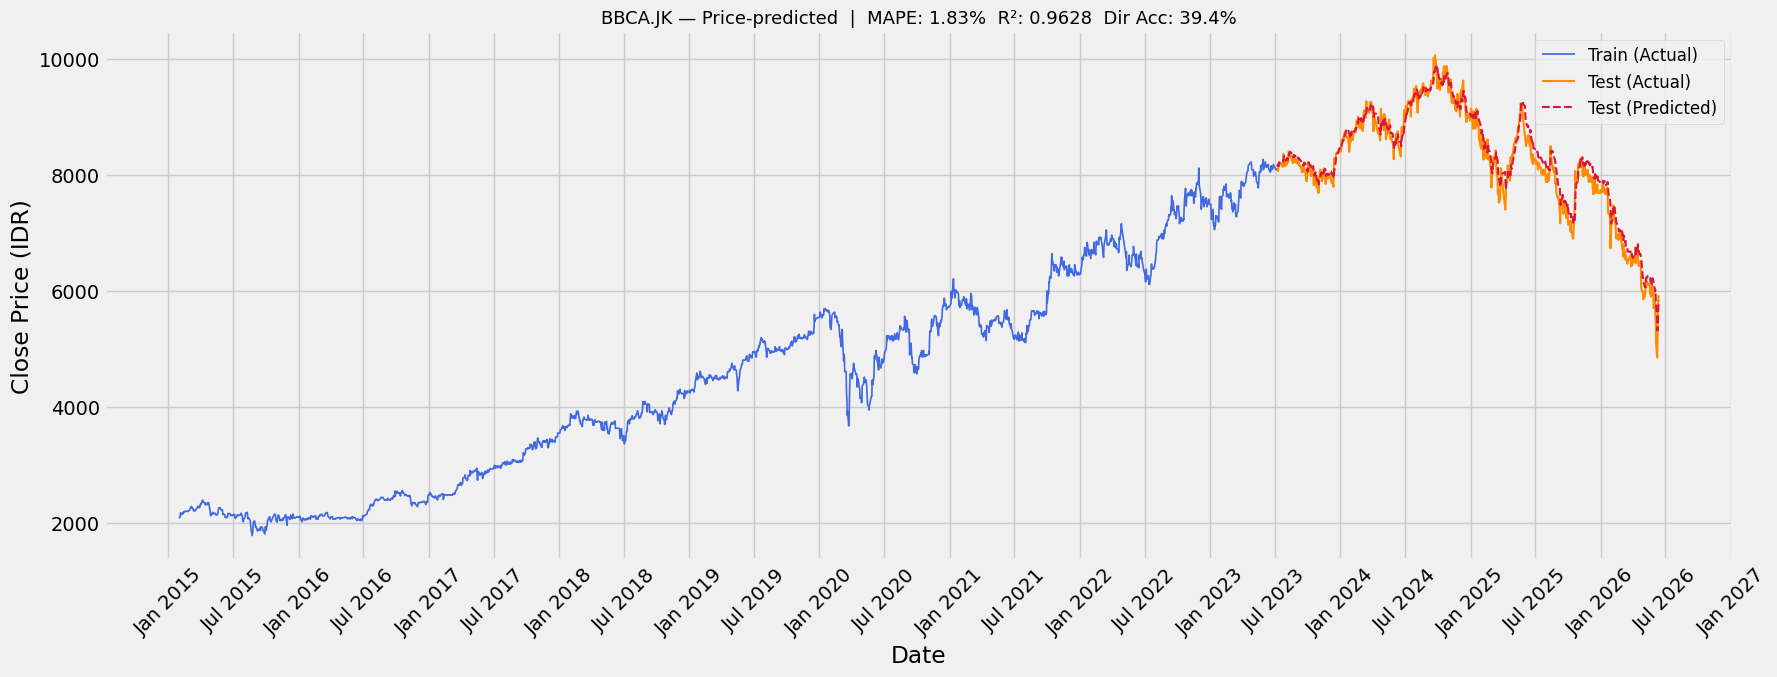

In [ ]:
# ── Prediction vs Actual ───────────────────────────────────────────────────────
n_test = len(actual_prices)
if PREDICT_RETURNS:
    test_dates = df.index[train_size : train_size + n_test]
else:
    test_dates = df.index[train_size:]

train_close = df['Close'].iloc[:train_size]

fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(train_close.index, train_close.values,
        color='royalblue', lw=1.2, label='Train (Actual)')
ax.plot(test_dates, actual_prices,
        color='darkorange', lw=1.5, label='Test (Actual)')
ax.plot(test_dates, pred_prices,
        color='crimson', lw=1.5, ls='--', label='Test (Predicted)')

mode_label = 'Return-predicted' if PREDICT_RETURNS else 'Price-predicted'
ax.set_title(f'{SYMBOL} — {mode_label}  |  MAPE: {mape:.2f}%  R²: {r2:.4f}  Dir Acc: {dir_acc:.1f}%',
             fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Close Price (IDR)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45); ax.legend(fontsize=12)
plt.tight_layout(); plt.show()

## 7. Lag & Residual Diagnostics

These plots answer: **"Is the model predicting or just echoing the past?"**

- **Lag plot**: if predictions look like actuals shifted by 1, the lag is still present
- **Durbin-Watson test**: DW ≈ 2.0 = no autocorrelation (good). DW < 1.5 = strong positive autocorrelation (model learned momentum, not dynamics)

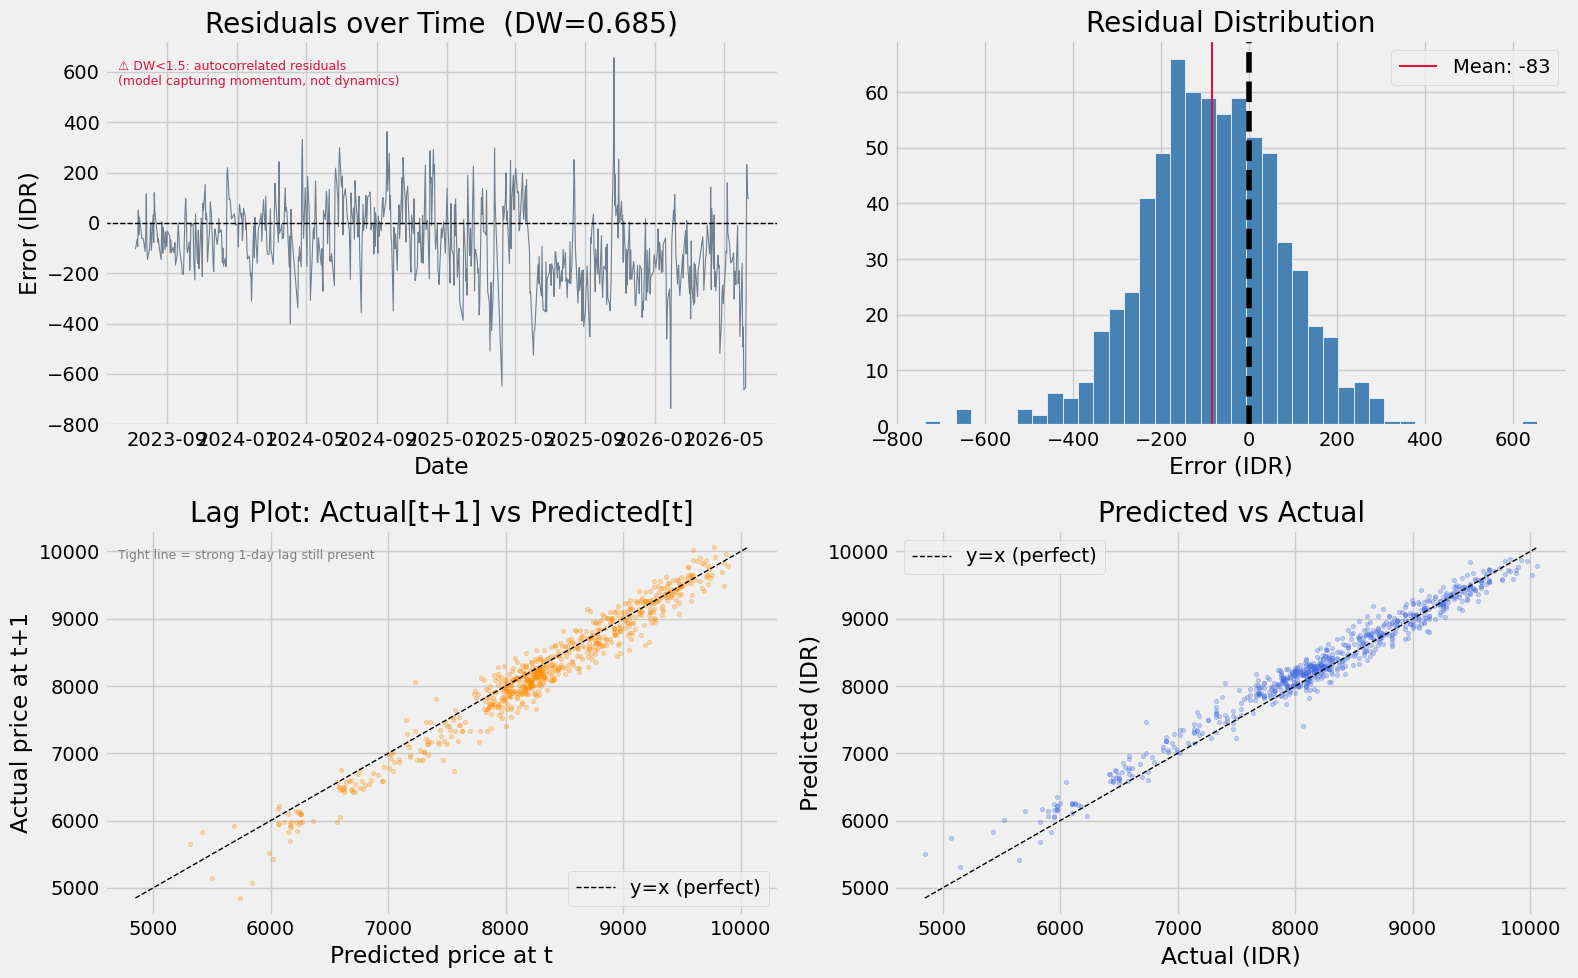


Durbin-Watson statistic: 0.6853
Interpretation:
  DW ≈ 2.0  → residuals are random (model captures real dynamics) ✅
  DW < 1.5  → positive autocorrelation (model is lagging) ⚠️
  DW > 2.5  → negative autocorrelation (model overcorrects) ⚠️
  Your DW   → autocorrelation detected


In [62]:
residuals = actual_prices - pred_prices
dw_stat   = durbin_watson(residuals)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residuals over time
axes[0,0].plot(test_dates, residuals, color='slategray', lw=0.8)
axes[0,0].axhline(0, color='black', ls='--', lw=1)
axes[0,0].set_title(f'Residuals over Time  (DW={dw_stat:.3f})')
axes[0,0].set_xlabel('Date'); axes[0,0].set_ylabel('Error (IDR)')
if dw_stat < 1.5:
    axes[0,0].text(0.02, 0.95, '⚠️ DW<1.5: autocorrelated residuals\n(model capturing momentum, not dynamics)',
                   transform=axes[0,0].transAxes, va='top', color='crimson', fontsize=9)
else:
    axes[0,0].text(0.02, 0.95, '✅ DW≈2: residuals not autocorrelated',
                   transform=axes[0,0].transAxes, va='top', color='seagreen', fontsize=9)

# 2. Residual distribution
axes[0,1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[0,1].axvline(0, color='black', ls='--')
axes[0,1].axvline(residuals.mean(), color='crimson', ls='-', lw=1.5,
                   label=f'Mean: {residuals.mean():.0f}')
axes[0,1].set_title('Residual Distribution')
axes[0,1].set_xlabel('Error (IDR)'); axes[0,1].legend()

# 3. Lag plot — actual[t+1] vs predicted[t]
# If there's a 1-day lag, this will look like a perfect straight line
axes[1,0].scatter(pred_prices[:-1], actual_prices[1:],
                   alpha=0.3, s=10, color='darkorange')
lims = [min(pred_prices.min(), actual_prices.min()),
        max(pred_prices.max(), actual_prices.max())]
axes[1,0].plot(lims, lims, 'k--', lw=1, label='y=x (perfect)')
axes[1,0].set_title('Lag Plot: Actual[t+1] vs Predicted[t]')
axes[1,0].set_xlabel('Predicted price at t'); axes[1,0].set_ylabel('Actual price at t+1')
axes[1,0].legend()
axes[1,0].text(0.02, 0.95,
               'Tight line = strong 1-day lag still present',
               transform=axes[1,0].transAxes, va='top', fontsize=9, color='gray')

# 4. Actual vs Predicted scatter (should be on y=x)
axes[1,1].scatter(actual_prices, pred_prices, alpha=0.3, s=10, color='royalblue')
axes[1,1].plot(lims, lims, 'k--', lw=1, label='y=x (perfect)')
axes[1,1].set_title('Predicted vs Actual')
axes[1,1].set_xlabel('Actual (IDR)'); axes[1,1].set_ylabel('Predicted (IDR)')
axes[1,1].legend()

plt.tight_layout(); plt.show()

print(f'\nDurbin-Watson statistic: {dw_stat:.4f}')
print('Interpretation:')
print('  DW ≈ 2.0  → residuals are random (model captures real dynamics) ✅')
print('  DW < 1.5  → positive autocorrelation (model is lagging) ⚠️')
print('  DW > 2.5  → negative autocorrelation (model overcorrects) ⚠️')
print(f'  Your DW   → {"residuals OK" if 1.5 < dw_stat < 2.5 else "autocorrelation detected"}')

## 8. Future Forecast (30 Days)

In [ ]:
def forecast_future(model, scaled_data, scaler, n_features, target_idx,
                    n_days, time_steps, n_simulations=100,
                    predict_returns=False, ret_scaler=None, last_close=None):

    all_runs = []
    for _ in range(n_simulations):
        buffer = scaled_data[-time_steps:].copy()
        preds  = []

        for _ in range(n_days):
            x_in = buffer[-time_steps:].reshape(1, time_steps, n_features)
            p = model(x_in, training=True).numpy()[0, 0]
            preds.append(p)
            new_row             = buffer[-1].copy()
            new_row[target_idx] = p
            buffer              = np.vstack([buffer, new_row])

        all_runs.append(preds)

    all_runs = np.array(all_runs)   # (n_simulations, n_days)
    mean_s = all_runs.mean(axis=0)
    lo_s   = np.percentile(all_runs, 5,  axis=0)
    hi_s   = np.percentile(all_runs, 95, axis=0)

    if predict_returns and ret_scaler is not None and last_close is not None:
        # Inverse-scale returns then reconstruct price path
        def returns_to_prices(scaled_rets, start_close):
            rets = ret_scaler.inverse_transform(
                scaled_rets.reshape(-1, 1)).flatten()
            prices = np.zeros(len(rets))
            prices[0] = start_close * (1 + rets[0])
            for i in range(1, len(rets)):
                prices[i] = prices[i-1] * (1 + rets[i])
            return prices
        mean_p = returns_to_prices(mean_s, last_close)
        lo_p   = returns_to_prices(lo_s,   last_close)
        hi_p   = returns_to_prices(hi_s,   last_close)
    else:
        mean_p = inverse_close(mean_s, scaler, n_features, target_idx)
        lo_p   = inverse_close(lo_s,   scaler, n_features, target_idx)
        hi_p   = inverse_close(hi_s,   scaler, n_features, target_idx)

    return mean_p, lo_p, hi_p


last_close = df['Close'].iloc[-1]

mean_fc, lo_fc, hi_fc = forecast_future(
    best_model, scaled, scaler, n_features, target_idx,
    FUTURE_DAYS, TIME_STEPS, n_simulations=100,
    predict_returns=PREDICT_RETURNS,
    ret_scaler=ret_scaler if PREDICT_RETURNS else None,
    last_close=last_close
)

last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FUTURE_DAYS)

forecast_df = pd.DataFrame({
    'Mean' : mean_fc,
    'Lower': lo_fc,
    'Upper': hi_fc
}, index=future_dates)

print(f'{FUTURE_DAYS}-Day Forecast (IDR):')
print(forecast_df.head(10).round(0).to_string())

30-Day Forecast (IDR):
              Mean   Lower   Upper
2026-06-15  6013.0  5793.0  6232.0
2026-06-16  6092.0  5836.0  6319.0
2026-06-17  6124.0  5873.0  6413.0
2026-06-18  6161.0  5958.0  6375.0
2026-06-19  6203.0  5995.0  6434.0
2026-06-22  6226.0  5955.0  6493.0
2026-06-23  6228.0  5951.0  6468.0
2026-06-24  6234.0  5958.0  6470.0
2026-06-25  6230.0  5982.0  6502.0
2026-06-26  6219.0  5901.0  6452.0


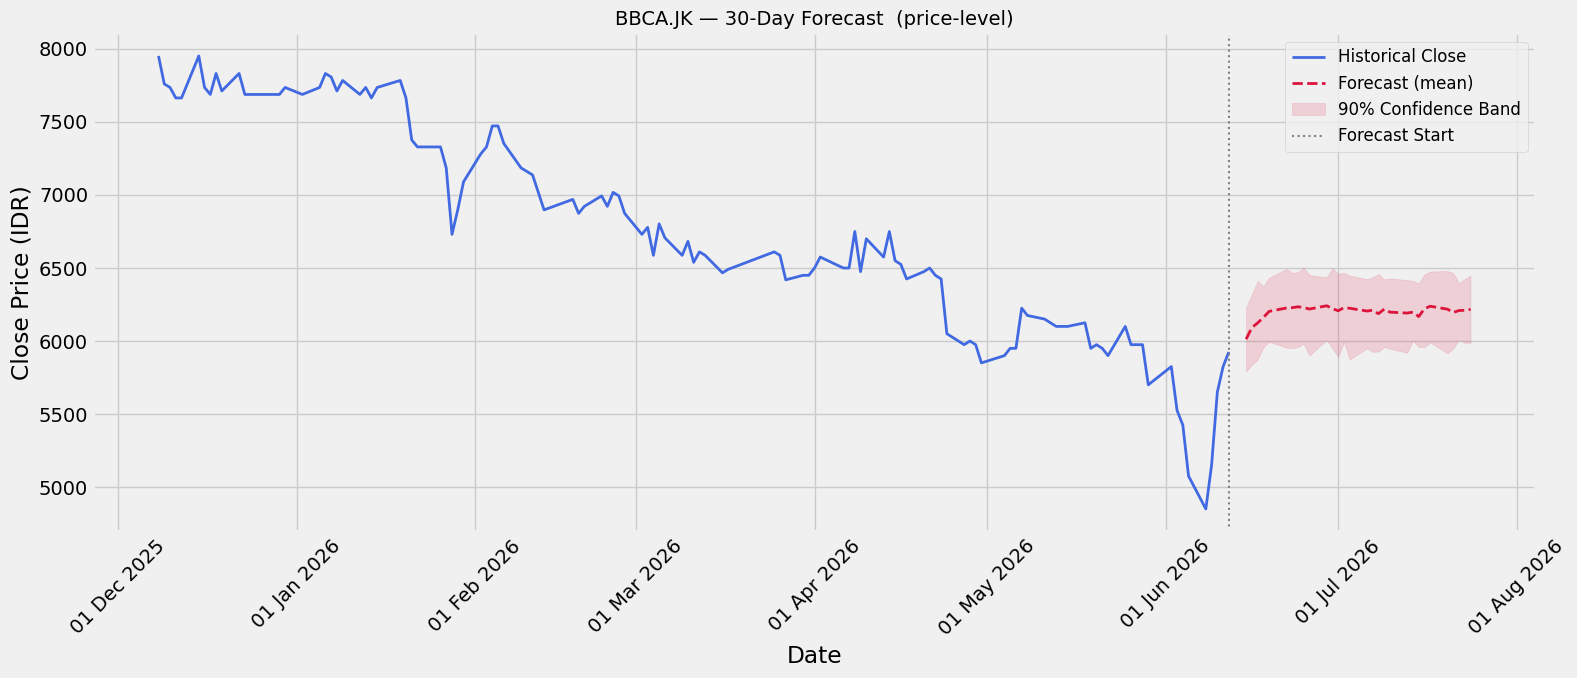

Last known Close : IDR 5,925
Forecast Day +30 : IDR 6,217
  90% CI         : IDR 5,987 – 6,448


In [68]:
# ── Forecast plot ─────────────────────────────────────────────────────────────
look_back  = 120
hist_slice = df['Close'].iloc[-look_back:]

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(hist_slice.index, hist_slice.values,
        color='royalblue', lw=2, label='Historical Close')
ax.plot(forecast_df.index, forecast_df['Mean'],
        color='crimson', lw=2, ls='--', label='Forecast (mean)')
ax.fill_between(forecast_df.index, forecast_df['Lower'], forecast_df['Upper'],
                color='crimson', alpha=0.15, label='90% Confidence Band')
ax.axvline(x=last_date, color='gray', ls=':', lw=1.5, label='Forecast Start')

ax.set_title(f'{SYMBOL} — {FUTURE_DAYS}-Day Forecast  '
             f'({"return-based" if PREDICT_RETURNS else "price-level"})', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Close Price (IDR)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45); ax.legend(fontsize=12)
plt.tight_layout(); plt.show()

print(f'Last known Close : IDR {last_close:,.0f}')
print(f'Forecast Day +{FUTURE_DAYS:02d} : IDR {forecast_df["Mean"].iloc[-1]:,.0f}')
print(f'  90% CI         : IDR {forecast_df["Lower"].iloc[-1]:,.0f} – {forecast_df["Upper"].iloc[-1]:,.0f}')

## 9. Save / Load

In [69]:
print(f'Best model saved to: {MODEL_PATH}')
# To reload:
# from keras.models import load_model
# model = load_model('bbca_lstm_best_v4.keras')

Best model saved to: bbca_lstm_best_v4.keras
